In [1]:
from transformers import pipeline

In [4]:
emotion = pipeline('sentiment-analysis', model='j-hartmann/emotion-english-distilroberta-base')

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: j-hartmann/emotion-english-distilroberta-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [5]:
emotion("I am very happy today!")

[{'label': 'joy', 'score': 0.9743683338165283}]

In [6]:
emotion("Today is a terrible day. I am feeling very sad and depressed.")

[{'label': 'sadness', 'score': 0.9796410799026489}]

In [7]:
import pandas as pd

In [8]:
df = pd.read_csv("text_emotion.csv")

In [9]:
df

,tweet_id,sentiment,author,content
0,1956967341,empty,xoshayzers,@tiffanylue i know i was listenin to bad habi...
1,1956967666,sadness,wannamama,Layin n bed with a headache ughhhh...waitin o...
2,1956967696,sadness,coolfunky,Funeral ceremony...gloomy friday...
3,1956967789,enthusiasm,czareaquino,wants to hang out with friends SOON!
4,1956968416,neutral,xkilljoyx,@dannycastillo We want to trade with someone w...
...,...,...,...,...
39995,1753918954,neutral,showMe_Heaven,@JohnLloydTaylor
39996,1753919001,love,drapeaux,Happy Mothers Day All my love
39997,1753919005,love,JenniRox,Happy Mother's Day to all the mommies out ther...
39998,1753919043,happiness,ipdaman1,@niariley WASSUP BEAUTIFUL!!! FOLLOW ME!! PEE...


In [10]:
df = df.sample(1000)

In [11]:
df

,tweet_id,sentiment,author,content
4117,1960211444,sadness,Sobk13,@mycaricature My pleasure and sorry to hear ab...
36793,1753380657,neutral,Fish_chat,Burp the Frog http://is.gd/rae9
9584,1962617024,sadness,chrisVEGGIE16,follow friday: following more people then foll...
31549,1751986770,happiness,LaurenLeakeElza,is excited about so R and R for mother's day
37651,1753518905,worry,jaysonstreet,@daveaitel I'm already here see you there!
...,...,...,...,...
26238,1695342261,worry,DaveChalmers1,@WirelessWoman yes but 75% are on the wrong wi...
22606,1694457176,happiness,grjsmith,"@ukdavew bank holiday Mondays rock, particular..."
17955,1965841889,hate,batchout,@inkswamp No FTP/Browser on the Mac I may vis...
29988,1751430365,neutral,shanonlee,"@rahsheen alright, I'll let you slide on that one"


In [12]:
df["content"][1:10].apply(emotion)

36793    [{'label': 'neutral', 'score': 0.8905853033065...
9584     [{'label': 'surprise', 'score': 0.543828487396...
31549      [{'label': 'joy', 'score': 0.7786679267883301}]
37651    [{'label': 'surprise', 'score': 0.676126718521...
4246       [{'label': 'joy', 'score': 0.9563577771186829}]
5915     [{'label': 'surprise', 'score': 0.890830636024...
30927    [{'label': 'surprise', 'score': 0.891259372234...
38987    [{'label': 'neutral', 'score': 0.4580294191837...
14315    [{'label': 'sadness', 'score': 0.6104470491409...
Name: content, dtype: object

In [13]:
def get_emotion_label(text):
    return (emotion(text)[0]['label'])

In [14]:
get_emotion_label("This is looking very terrible")

'fear'

In [15]:
df["content"][1:10].apply(get_emotion_label)

36793     neutral
9584     surprise
31549         joy
37651    surprise
4246          joy
5915     surprise
30927    surprise
38987     neutral
14315     sadness
Name: content, dtype: object

In [16]:
df["emotion"] = df["content"].apply(get_emotion_label)

In [17]:
df

,tweet_id,sentiment,author,content,emotion
4117,1960211444,sadness,Sobk13,@mycaricature My pleasure and sorry to hear ab...,sadness
36793,1753380657,neutral,Fish_chat,Burp the Frog http://is.gd/rae9,neutral
9584,1962617024,sadness,chrisVEGGIE16,follow friday: following more people then foll...,surprise
31549,1751986770,happiness,LaurenLeakeElza,is excited about so R and R for mother's day,joy
37651,1753518905,worry,jaysonstreet,@daveaitel I'm already here see you there!,surprise
...,...,...,...,...,...
26238,1695342261,worry,DaveChalmers1,@WirelessWoman yes but 75% are on the wrong wi...,sadness
22606,1694457176,happiness,grjsmith,"@ukdavew bank holiday Mondays rock, particular...",joy
17955,1965841889,hate,batchout,@inkswamp No FTP/Browser on the Mac I may vis...,neutral
29988,1751430365,neutral,shanonlee,"@rahsheen alright, I'll let you slide on that one",neutral


In [18]:
import seaborn as sns

Text(0.5, 1.0, 'Emotion Detection')

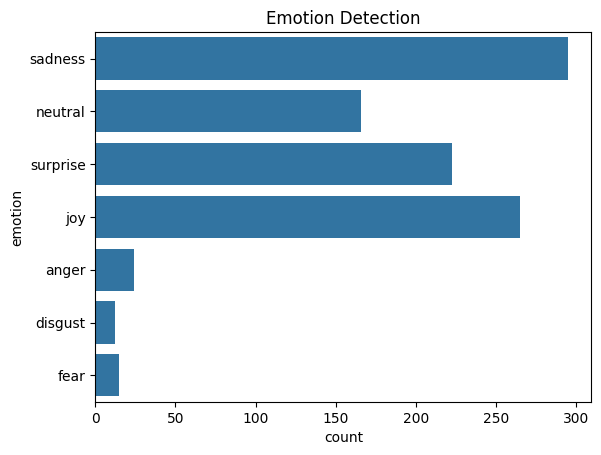

In [19]:
sns.countplot(y="emotion", data=df).set_title("Emotion Detection")

In [20]:
emotion("I am very sad today. I got my dream job")

[{'label': 'sadness', 'score': 0.9861660003662109}]

In [24]:
emotion("I am very very not happy today")

[{'label': 'sadness', 'score': 0.9896668195724487}]

In [25]:
emotion("I got the job")

[{'label': 'joy', 'score': 0.9393830299377441}]

In [26]:
emotion("Today is Monday")

[{'label': 'neutral', 'score': 0.840295672416687}]

In [38]:
emotion("You Sucks")

[{'label': 'disgust', 'score': 0.5562874674797058}]

In [39]:
emotion("Bravo you lose")

[{'label': 'neutral', 'score': 0.5798792243003845}]

In [40]:
emotion("Alas! You are alive!")

[{'label': 'surprise', 'score': 0.6400071382522583}]